In [274]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
import math

sns.set_theme(style='whitegrid')


# Figure 1: Plotting Original Points

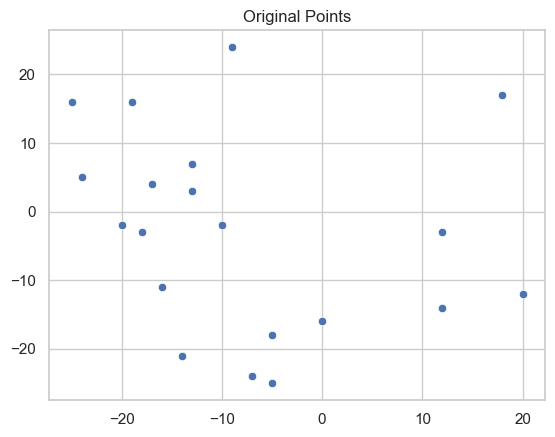

In [275]:
num_points = 20
np.random.seed(1)
x_orig = np.random.randint(low=-25, high=25, size=num_points)
y_orig = np.random.randint(low=-25, high=25, size=num_points)

plt.figure()
sns.scatterplot(x=x_orig, y=y_orig)
plt.title("Original Points")
plt.show()


# Figure 2: Convex Hull
Only points on the convex hull can be included on the voronoi diagram


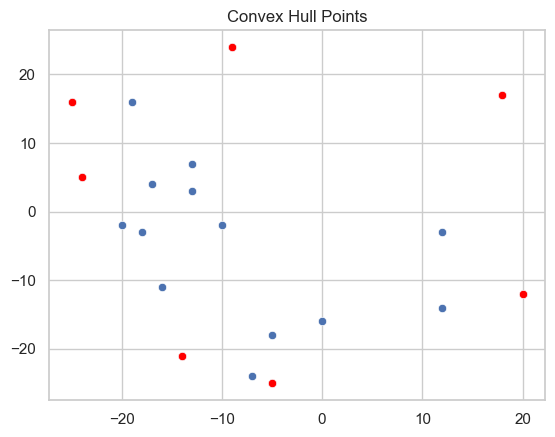

In [276]:
convex_hull = sp.spatial.ConvexHull(np.column_stack((x_orig, y_orig)))
hull_indices = convex_hull.vertices

plt.figure()
sns.scatterplot(x=x_orig, y=y_orig)
sns.scatterplot(x=x_orig[hull_indices], y=y_orig[hull_indices], color='red')
plt.title("Convex Hull Points")
plt.show()


In [277]:
x = x_orig[hull_indices]
y = y_orig[hull_indices]
N_pts = len(x)


# Figure 3: Lifted Paraboloid
Following the steps of Delaunay Triangulation

In [278]:
z = x**2 + y**2
z


array([650, 544, 613, 657, 881, 601, 637], dtype=int32)

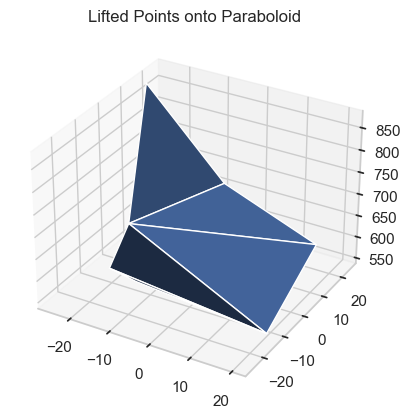

In [279]:
fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
ax.plot_trisurf(x, y, z)
plt.title("Lifted Points onto Paraboloid")
plt.show()


In [280]:
convex_3d = sp.spatial.ConvexHull(points=np.column_stack((x, y, z)))


Equations are the planes of the convex hull described as the components of the normal vector + the offset, or 

$ \vec{n} + b $


In [281]:
convex_3d.equations[0]


array([   0.88459993,   -0.43995275,    0.15467559, -107.11495276])

We can determine which faces are pointing upwards by only keeping the faces that have 

$ \vec{n} \cdot \hat{k} > 0 $


In [282]:
k = [0, 0, 1]  # k-hat, or the z basis vector
valid = np.empty(len(convex_3d.equations), dtype=bool)

for i, eq in enumerate(convex_3d.equations):
    if np.dot(k, eq[:-1]) > 0:
        valid[i] = True
    else:
        valid[i] = False


# Creating a Point class 
This organizes adjacency between convex hull faces (simplices), circumcenters, and points before Farthest-Delaunay Triangulation Projection


In [283]:
class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.adjacency = []
        self.simplices = []
        self.circumcenters = []


In [284]:
points = []
for x_i, y_i in zip(x, y):
    points.append(Point(x_i, y_i))


In [285]:
def plot_simplex(x, y, simplex, ax=None):
    if ax is None:
        ax = plt.gca()
    line1 = [simplex[0], simplex[1]]
    line2 = [simplex[1], simplex[2]]
    line3 = [simplex[0], simplex[2]]
    
    for line in [line1, line2, line3]:
        ax.plot(x[line], y[line])


In [286]:
def set_adjacency(points, simplex):
    s = simplex.copy()
    shift = 1
    for row in simplex:
        neighbors = np.roll(s, shift)[1:]
        for n in neighbors:
            if n not in points[row].adjacency:
                points[row].adjacency.append(n)
        shift += 1


In [287]:
def get_circumcenter(x, y, simplex):
    x1, x2, x3 = x[simplex[0]], x[simplex[1]], x[simplex[2]]
    y1, y2, y3 = y[simplex[0]], y[simplex[1]], y[simplex[2]]
    
    d = 2 * (x1 * (y2 - y3) + x2 * (y3 - y1) + x3 * (y1 - y2))

    a_sq = x1**2 + y1**2
    b_sq = x2**2 + y2**2
    c_sq = x3**2 + y3**2

    u = (a_sq * (y2 - y3) + b_sq * (y3 - y1) + c_sq * (y1 - y2)) / d
    v = (a_sq * (x3 - x2) + b_sq * (x1 - x3) + c_sq * (x2 - x1)) / d
    
    return u, v


In [288]:
valid_simplices = []
for i, simplex in enumerate(convex_3d.simplices):
    if valid[i]:
        valid_simplices.append(simplex)
        u, v = get_circumcenter(x, y, simplex)
        set_adjacency(points, simplex)
        for row in simplex:
            points[row].simplices.append(simplex)
            points[row].circumcenters.append((u, v))


# Figure 4: Farthest-Point Delaunay Triangulation

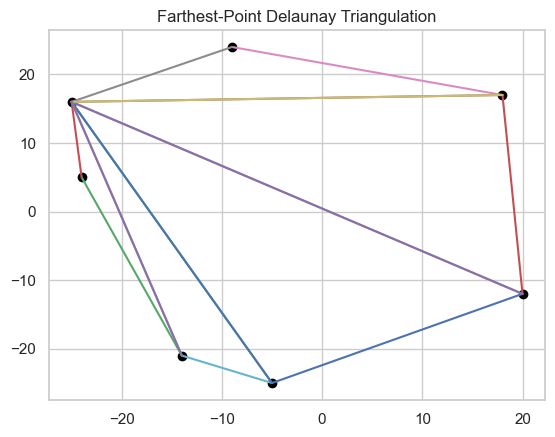

In [289]:
fig, ax = plt.subplots()
for simplex in valid_simplices:
    plot_simplex(x, y, simplex, ax)
ax.scatter(x, y, color='black')
plt.title("Farthest-Point Delaunay Triangulation")
plt.show()


# Figure 5: Farthest-Point Voronoi Diagram (lines only)
To create the farthest-delaunay voronoi diagram, you simply find the connected components of the circumcenters of the farthest-delaunay triangulation.


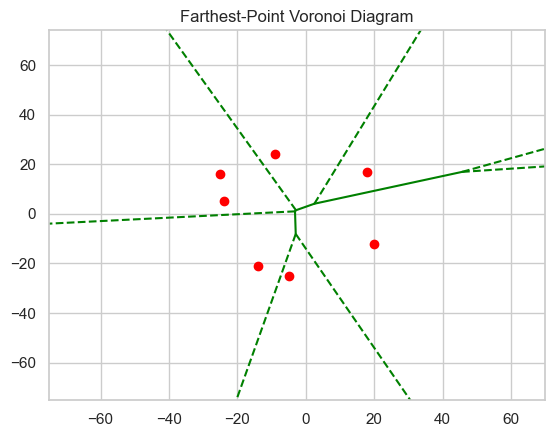

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x, y, color='red')

# To form the Farthest-Point Voronoi Diagram, the vertices of the cells are exactly
# the circumcenters of the Farthest-Point Delaunay triangulation.
cc_list = [get_circumcenter(x, y, s) for s in valid_simplices]

# Drawing Bounded Voronoi Edges:
# If two triangles in the Delaunay triangulation share an edge (exactly 2 vertices),
# their corresponding circumcenters are connected by a bounded Voronoi edge.
for i in range(len(valid_simplices)):
    for j in range(i + 1, len(valid_simplices)):
        shared_vertices = set(valid_simplices[i]).intersection(
            set(valid_simplices[j]))
        if len(shared_vertices) == 2:
            cc1 = cc_list[i]
            cc2 = cc_list[j]
            ax.plot([cc1[0], cc2[0]], [cc1[1], cc2[1]], color='green')

# Finding Boundary Edges of the Triangulation:
# A boundary edge of the triangulation belongs to only one valid simplex. 
# We map each edge to the indices of the simplices that contain it.
edge_counts = {}
for i, simplex in enumerate(valid_simplices):
    edges = [
        tuple(sorted([simplex[0], simplex[1]])),
        tuple(sorted([simplex[1], simplex[2]])),
        tuple(sorted([simplex[0], simplex[2]]))
    ]
    for edge in edges:
        if edge not in edge_counts:
            edge_counts[edge] = []
        edge_counts[edge].append(i)

# rays_for_point will store the distant "infinity" points to later close the Voronoi cells
rays_for_point = {i: [] for i in range(N_pts)}

# Drawing Unbounded Voronoi Edges (Rays):
# For edges on the boundary of the hull, the Voronoi edge extends to infinity.
# It is the perpendicular bisector of the boundary edge.
for edge, simplices_indices in edge_counts.items():
    if len(simplices_indices) == 1:
        # Get the single simplex containing this boundary edge
        simplex_idx = simplices_indices[0]
        simplex = valid_simplices[simplex_idx]

        # cc represents the origin of our ray (the simplex's circumcenter)
        cc = cc_list[simplex_idx]

        A, B = edge
        # Identify the third vertex C of the triangle to help orient our ray
        C = next(v for v in simplex if v != A and v != B)

        # Compute the direction vector of the edge AB
        dx = x[B] - x[A]
        dy = y[B] - y[A]

        # Determining the Ray Direction (Inward Normal):
        # N_vec is a perpendicular vector to the edge AB.
        N_vec = np.array([-dy, dx], dtype=float)

        # We need the ray to point TOWARDS the interior of the polygon for a Farthest-Point Voronoi Diagram
        # (Unlike an ordinary Voronoi diagram where rays point outward).
        # We check the dot product of N_vec and the vector AC. If it is negative, N_vec is pointing
        # away from vertex C (outward), so we flip it to point inward.
        AC = np.array([x[C] - x[A], y[C] - y[A]], dtype=float)
        if np.dot(N_vec, AC) < 0:
            N_vec = -N_vec

        norm = np.linalg.norm(N_vec)
        if norm > 0:

            N_vec = N_vec / norm

            # Extend the ray far into the distance (acting as our point at infinity)
            ray_end = (cc[0] + N_vec[0] * 5000, cc[1] + N_vec[1] * 5000)

            # Plot the dashed ray separating the respective farthest-point regions
            ax.plot([cc[0], ray_end[0]], [cc[1], ray_end[1]],
                    color='green', linestyle='dashed')

            # Save the point at infinity for later when we color the regions of points A and B
            rays_for_point[A].append(ray_end)
            rays_for_point[B].append(ray_end)

zoom = 50
ax.set_xlim(min(x) - zoom, max(x) + zoom)
ax.set_ylim(min(y) - zoom, max(y) + zoom)
plt.title("Farthest-Point Voronoi Diagram")
plt.show()

# Figure 6: Colored Farthest-Point Voronoi Diagram

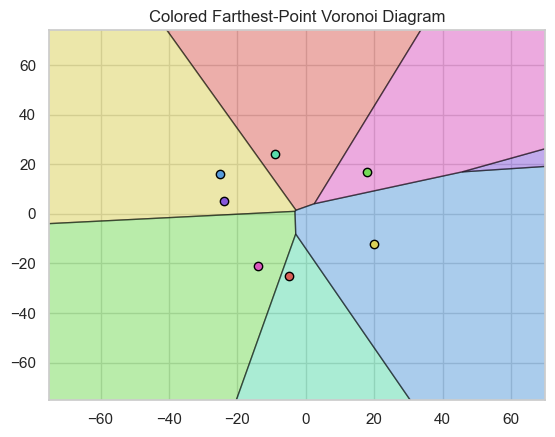

In [291]:
fig, ax = plt.subplots()
colors = sns.color_palette("hls", N_pts)

for i in range(N_pts):
    # Combine the true Voronoi vertices and ray extensions to infinity
    cell_verts = points[i].circumcenters + rays_for_point[i]
    if len(cell_verts) >= 3:
        # Sort vertices counterclockwise around their centroid
        cx = sum(v[0] for v in cell_verts) / len(cell_verts)
        cy = sum(v[1] for v in cell_verts) / len(cell_verts)
        cell_verts.sort(key=lambda v: math.atan2(v[1] - cy, v[0] - cx))

        poly = plt.Polygon(
            cell_verts, facecolor=colors[i], edgecolor='black', alpha=0.5)
        ax.add_patch(poly)

    # Plot the point itself with the same color
    ax.scatter(x[i], y[i], color=colors[i], edgecolor='black', zorder=5)

ax.set_xlim(min(x) - zoom, max(x) + zoom)
ax.set_ylim(min(y) - zoom, max(y) + zoom)
plt.title("Colored Farthest-Point Voronoi Diagram")

plt.show()

# Complexity Analysis

Algorithm description:

1. Get convex hull of all points and discard all others $O(n \log{n})$
2. Project each point onto the $x^2 + y^2$ paraboloid $O(n)$
3. Calculate the 3D-convex hull of the projected points $O(n \log{n})$
4. Keep only the faces that are facing upwards $O(n)$
5. Comparison of all simplicies with each other $O(n^2)$, but this could be reduced to $O(n)$ with dictionaries, but I did not do this
6. Drawing all bisectors for neighboring points $O(n)$

Overall, my algorithm is $O(n^2)$

# Correctness
The algorithm follows the process of the already proven paraboloid projection method for Delaunay Triangulation. Rather than taking the points that are closest, we want the region that is *furthest*. For this reason, we take the upper faces of the convex hull, such that the region preserved, relative to a face, corresponds to the points that are furthest away from the vertices of that faces (when projected back down). 

Once we project these 3D upper faces back down, the 2D plane gives us the Farthest-Point Delaunay Triangulation. 

Once the triangulation is finished, the duality to a Voronoi diagram can be leveraged to construct the diagram. The Voronoi vertices are the circumcenters of the triangles. Like the normal Delaunay Triangulation, we can draw edges between circumcenters of triangles that share edges, or two vertices. A critical difference lies in the unbounded regions of the Voronoi diagram, since the furthest-point region is inherently unbounded. This means we have to extend a ray along the perpendicular bisector of the boundary edge and the ray must point inward to cross the center of the polygon, defining the half-plane horizon where each outer vertex becomes the furthest point.

# References

- https://drops.dagstuhl.de/storage/00lipics/lipics-vol349-wads2025/LIPIcs.WADS.2025.48/LIPIcs.WADS.2025.48.pdf
- https://www.cis.upenn.edu/~jean/gbooks/new281-282.pdf 
- https://www.wias-berlin.de/people/si/course/files/Aurenhammer91-Voronoi.pdf 

IEEE Format:
- F. Aurenhammer, "Voronoi Diagrams — A Survey of a Fundamental Geometric Data Structure," ACM Computing Surveys (CSUR), vol. 23, no. 3, pp. 361, Sep. 1991.
- M. Song, M. K. Jung, and H. K. Ahn, "Farthest-Point Voronoi Diagrams in the Hilbert Metric," in Proc. 19th Int. Symp. Algorithms and Data Structures (WADS 2025), P. Morin and E. Oh, Eds. Dagstuhl, Germany: Schloss Dagstuhl – Leibniz-Zentrum für Informatik, 2025, Art. no. 48, pp. 48:1–48:15 . doi: 10.4230/LIPIcs.WADS.2025.48.
- J. Gallier, "Delaunay Triangulations and Convex Hulls," in Geometric Methods and Applications: For Computer Science and Engineering, 2nd ed. New York, NY, USA: Springer, 2011, ch. 9, sec. 4, pp. 281–282.